In [ ]:
import pandas as pd

## 1. Data Loading & Preprocessing
First, we load the dataset and handle the **Object column** (the target) by encoding it into numbers.

In [2]:
df = pd.read_csv('iris.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
pd.isnull(df).sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [11]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data is ready for training!")
df.head()

Data is ready for training!


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2. Decision Tree Modeling
We will use `max_depth=3`. This is a crucial step in Level 2 to demonstrate **Pruning**, which ensures the model generalizes well and doesn't just memorize the training data.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_clf.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully.")

Decision Tree Model Trained Successfully.


## 3. Tree Visualization 📊
This is the most important part of this task. We can actually "see" the rules the model learned.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

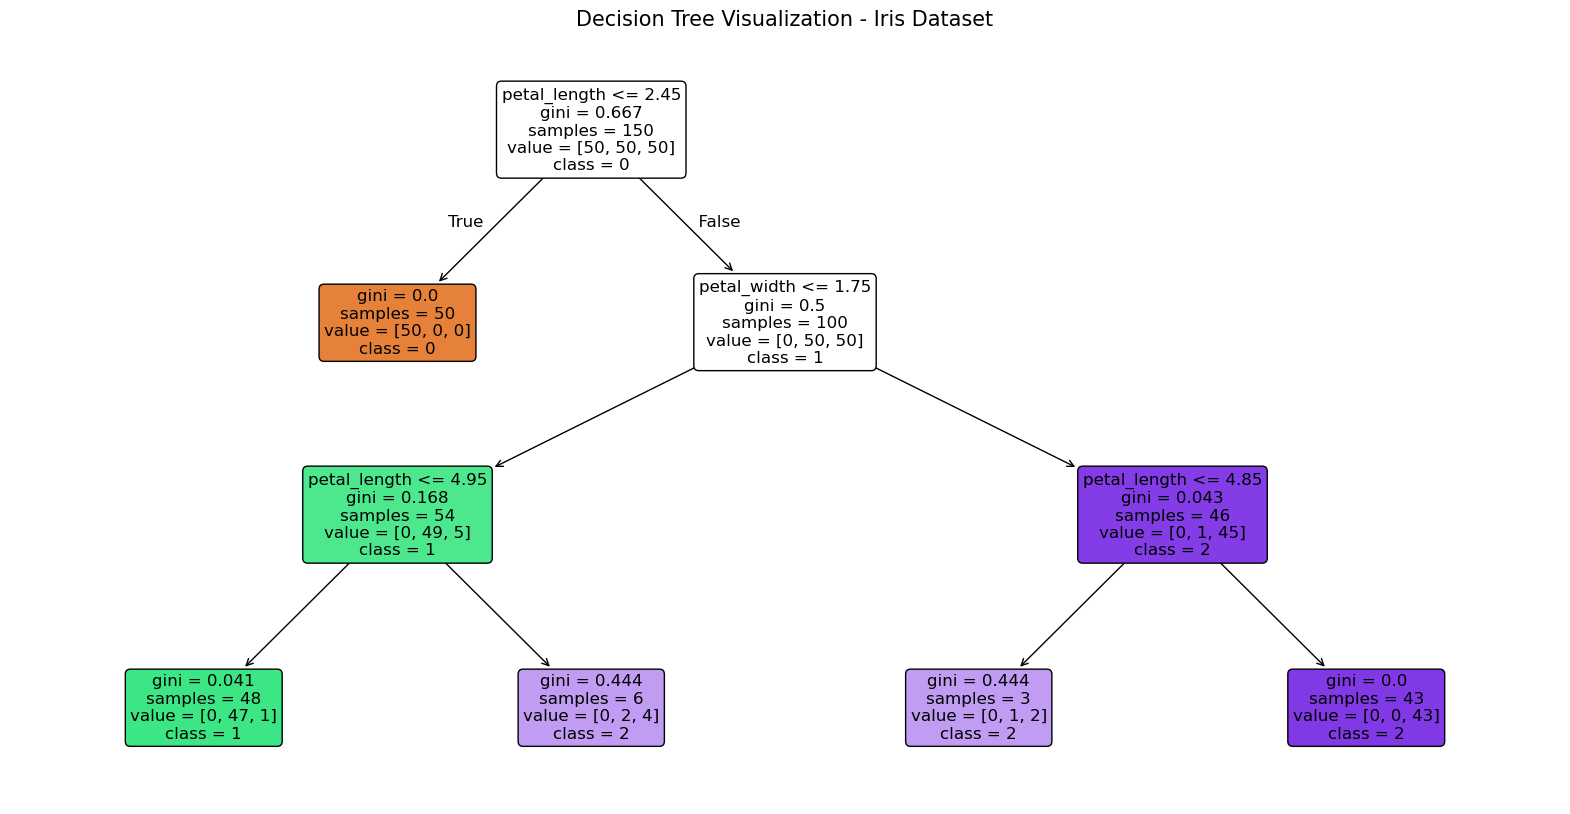

In [26]:
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, 
          feature_names=X.columns.tolist(), 
          class_names=[str(c) for c in le.classes_], 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.title("Decision Tree Visualization - Iris Dataset", fontsize=15)
plt.show()

## 4. Performance Evaluation
Finally, let's check how our model performs on the test data.

Accuracy: 100.00%

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



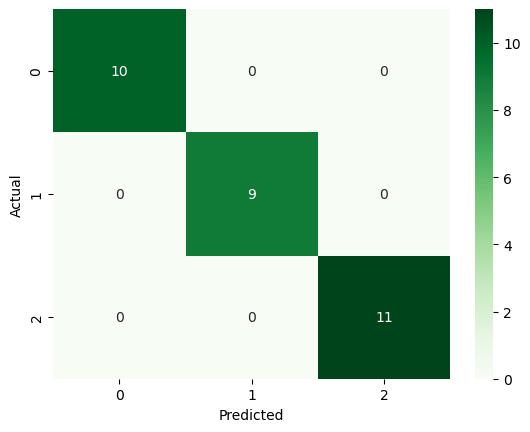

In [ ]:
y_pred = dt_clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()